In [1]:
%load_ext autoreload
%autoreload 2

https://www.10xgenomics.com/analysis-guides/segmentation-visium-hd

In [1]:
import os
import sparrow as sp
import spatialdata as sd
from matplotlib import pyplot as plt
import seaborn as sns

the value of the environment variable BASIC_DCT_BACKEND is not in ["JAX","SCIPY"]
2025-06-17 17:55:41,704 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.im.flowsom' will not be available.
2025-06-17 17:55:41,723 - sparrow.table.cell_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.tb.flowsom' will not be available.
2025-06-17 17:55:41,736 - sparrow.plot - WARNING - 'joypy' not installed, 'sp.pl.ridgeplot_channel' and 'sp.pl.ridgeplot_channel_sample' will not be available.
2025-06-17 17:55:41,737 - sparrow.plot - WARNING - 'textalloc' not installed, 'sp.pl.group_snr_ratio' and 'sp.pl.snr_ratio' will not be available.


In [2]:
#path = "/home/chananchidas/visium-hd/data/example_datasets" # pick a path where the zarr store will be saved
#sdata=sp.datasets.visium_hd_example( bin_size=[ 2, 8, 16 ], output = os.path.join( path, "sdata_custom_binning_example.zarr" ) )
sdata = sd.read_zarr("/home/chananchidas/visium-hd/data/example_datasets/sdata_custom_binning_example.zarr")


/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument '

create a grid of 16 micron

In [3]:
# From /run/media/chananchidas/T7 Touch/visium-hd_17062025/data/Visium_HD_SmallIntestine/binned_outputs/square_016um/spatial/scalefactors_json.json
# "spot_diameter_fullres" (i.e., pixels of spot diameter)
size = 58.44508306958184
# take shape of grid equal to full h&e image
se = sdata[ "Visium_HD_Mouse_Small_Intestine_full_image" ][ "scale0" ][ "image" ]
sdata = sp.im.add_grid_labels_layer( sdata, shape = se.shape[1:], size=size, output_shapes_layer="square_shapes", output_labels_layer="square_labels", grid_type="square", overwrite=True )

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument '

In [4]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/example_datasets/sdata_custom_binning_example.zarr
├── Images
│     ├── 'Visium_HD_Mouse_Small_Intestine_full_image': DataTree[cyx] (3, 21943, 23618), (3, 10971, 11809), (3, 5485, 5904), (3, 2742, 2952), (3, 1371, 1476)
│     ├── 'Visium_HD_Mouse_Small_Intestine_hires_image': DataArray[cyx] (3, 5575, 6000)
│     └── 'Visium_HD_Mouse_Small_Intestine_lowres_image': DataArray[cyx] (3, 558, 600)
├── Labels
│     ├── 'Visium_HD_Mouse_Small_Intestine_square_002um_labels': DataArray[yx] (3285, 3191)
│     ├── 'Visium_HD_Mouse_Small_Intestine_square_008um_labels': DataArray[yx] (822, 799)
│     ├── 'Visium_HD_Mouse_Small_Intestine_square_016um_labels': DataArray[yx] (412, 400)
│     └── 'square_labels': DataArray[yx] (21943, 23618)
├── Shapes
│     ├── 'Visium_HD_Mouse_Small_Intestine_square_002um': GeoDataFrame shape: (5479660, 1) (2D shapes)
│     ├── 'Visium_HD_Mouse_Small_Intestine_square_008um': GeoDataFrame

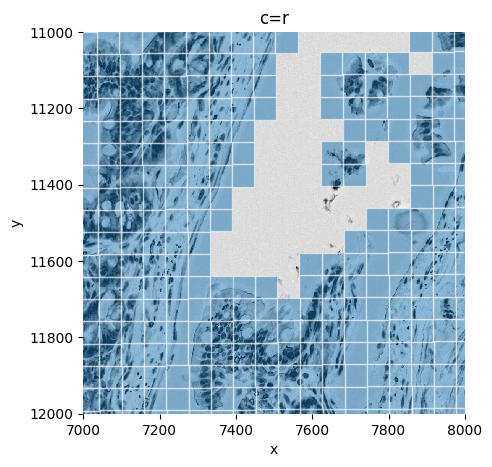

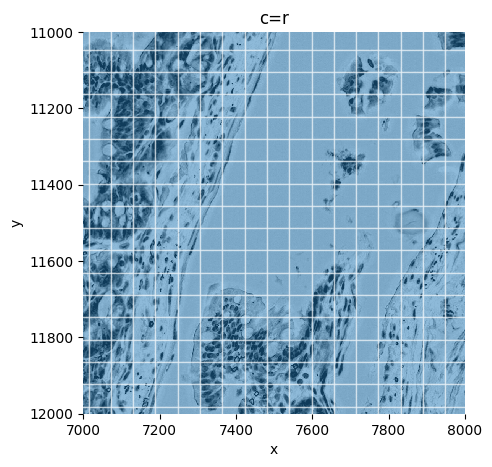

In [5]:
# lets plot the real grid next to the custom grid
sp.pl.plot_shapes( sdata,
                  img_layer="Visium_HD_Mouse_Small_Intestine_full_image",
                  shapes_layer="Visium_HD_Mouse_Small_Intestine_square_016um", 
                  crd = [7000,8000,11000, 12000],
                  channel = "r",
                  figsize=(5,5)
                   )

# lets plot the grid
sp.pl.plot_shapes( sdata,
                  img_layer="Visium_HD_Mouse_Small_Intestine_full_image",
                  shapes_layer="square_shapes", 
                  crd = [7000,8000,11000, 12000],
                  channel = "r",
                  figsize=(5,5)
                   )

In [6]:
# now do a custom binning using the generated labels layer 'square_labels'.
# below step should be quite fast, 50-ish seconds on mac m2
sdata=sp.tb.bin_counts( 
    sdata,
    table_layer="square_002um",
    labels_layer="square_labels",
    output_layer="table_custom_bins",
    append = False,
    overwrite=True,
      )

2025-06-17 17:56:46,012 - sparrow.table._allocation - INFO - Calculating cell counts.
2025-06-17 17:57:07,910 - sparrow.table._allocation - INFO - 
 Number of spots per bin  Frequency
                       1        165
                       2        398
                       3        190
                       4        327
                       5        133
                       6        287
                       7         96
                       8        444
                       9        102
                      10        180
                      11        112
                      12        209
                      13         47
                      14        230
                      15         96
                      16        348
                      17         78
                      18        156
                      19         68
                      20        190
                      21         74
                      22        170
                      23

In [7]:
sdata["square_labels"]

<xarray.DataArray 'image' (y: 21943, x: 23618)> Size: 2GB
dask.array<from-zarr, shape=(21943, 23618), dtype=uint32, chunksize=(5583, 6009), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 176kB 0.5 1.5 2.5 3.5 ... 2.194e+04 2.194e+04 2.194e+04
  * x        (x) float64 189kB 0.5 1.5 2.5 3.5 ... 2.362e+04 2.362e+04 2.362e+04
Attributes:
    transform:  {'global': Identity }

In [10]:
sdata["table_custom_bins"].obs

,cell_ID,fov_labels
cells,,
339_square_labels_8a010ca0,339,square_labels
340_square_labels_8a010ca0,340,square_labels
341_square_labels_8a010ca0,341,square_labels
744_square_labels_8a010ca0,744,square_labels
745_square_labels_8a010ca0,745,square_labels
...,...,...
150048_square_labels_8a010ca0,150048,square_labels
150049_square_labels_8a010ca0,150049,square_labels
151241_square_labels_8a010ca0,151241,square_labels


In [9]:
sdata["square_shapes"]

,geometry
1,"POLYGON ((0 0, 58.445 0, 58.445 58.445, 0 58.4..."
2,"POLYGON ((58.445 0, 116.89 0, 116.89 58.445, 5..."
3,"POLYGON ((116.89 0, 175.335 0, 175.335 58.445,..."
4,"POLYGON ((175.335 0, 233.78 0, 233.78 58.445, ..."
5,"POLYGON ((233.78 0, 292.225 0, 292.225 58.445,..."
...,...
151496,"POLYGON ((23319.588 21858.461, 23378.033 21858..."
151497,"POLYGON ((23378.033 21858.461, 23436.478 21858..."
151498,"POLYGON ((23436.478 21858.461, 23494.923 21858..."
151499,"POLYGON ((23494.923 21858.461, 23553.368 21858..."


Plot real vs custom binned data

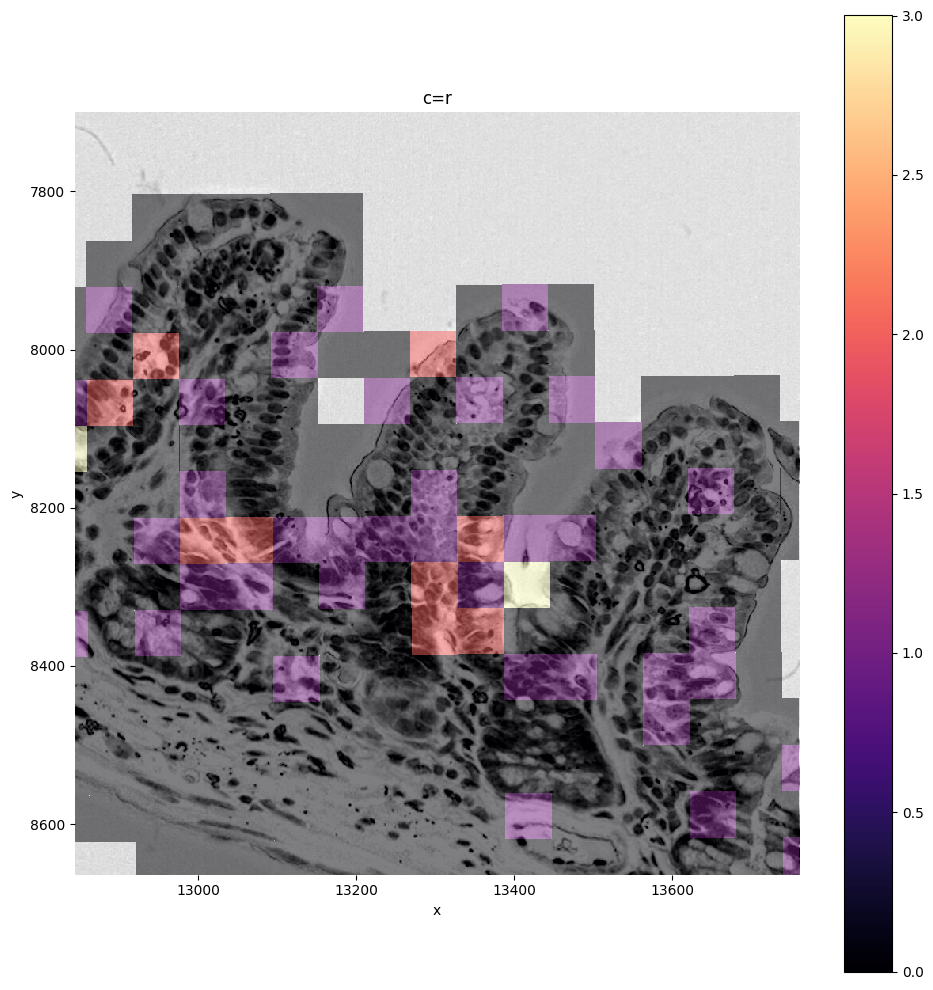

In [6]:
sp.pl.plot_shapes(
    sdata,
    img_layer = "Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="Visium_HD_Mouse_Small_Intestine_square_016um",
    crd = [ 12844, 13760, 7700, 8664 ],
    channel="r",
    table_layer = "square_016um",
    column="Lypla1",
    linewidth=0,
      )

2025-06-17 17:58:28,868 - sparrow.plot._plot - WARNING - There are '86' cells in provided shapes_layer 'square_shapes' not found in 'sdata.tables[table_custom_bins]' (linked through 'cell_ID'), these cells will not be plotted.


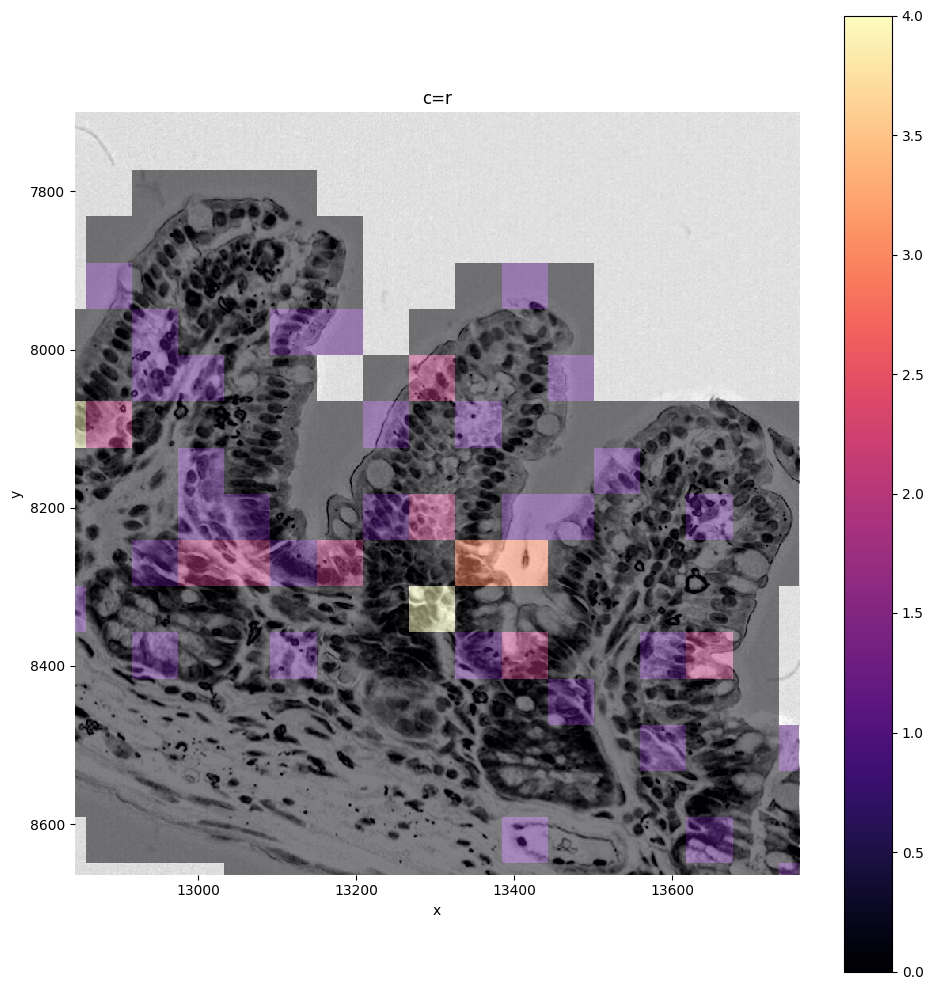

In [11]:
sp.pl.plot_shapes(
    sdata,
    img_layer = "Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="square_shapes",
    crd = [ 12844, 13760, 7700, 8664 ],
    channel="r",
    table_layer = "table_custom_bins",
    column="Lypla1",
    linewidth=0,
      )

They don't look completely alike, but this could be due to offsets. If we look at the shape of the tables, it is close enough. Now let's try to look at the general trends of the data.

In [17]:
print(sdata['square_016um'].shape)
print(sdata['table_custom_bins'].shape)

(91033, 19059)
(90942, 19059)


Text(0, 0.5, '')

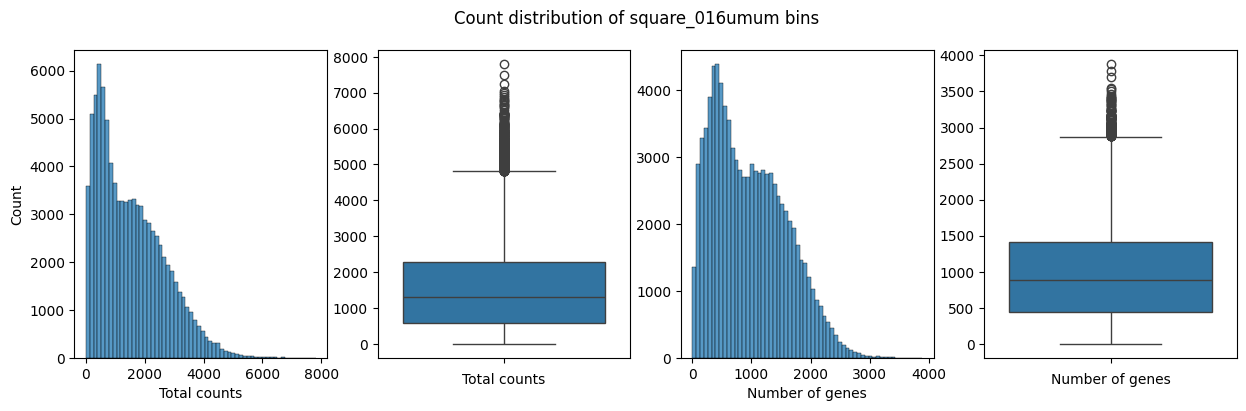

In [ ]:
# Count distribution per bin size
adata = sdata.tables["square_016um"]
adata.obs["total_counts"] = adata.X.sum(axis=1)
adata.obs["n_genes_by_counts"] = (adata.X > 0).sum(axis=1)

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])

sns.boxplot(adata.obs["total_counts"], ax=axs[1])
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])

# Set overall title
fig.suptitle("Count distribution of {}um bins".format("square_016um"))

# Set title and labels
axs[0].set_xlabel("Total counts")
axs[1].set_xlabel("Total counts")
axs[2].set_xlabel("Number of genes")
axs[3].set_xlabel("Number of genes")

# Turn off y-axis title
axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[3].set_ylabel("")

# Save plot
# plt.savefig("plots/histogram_count_genes_{}um.png".format(bin_size), dpi=300)

Text(0, 0.5, '')

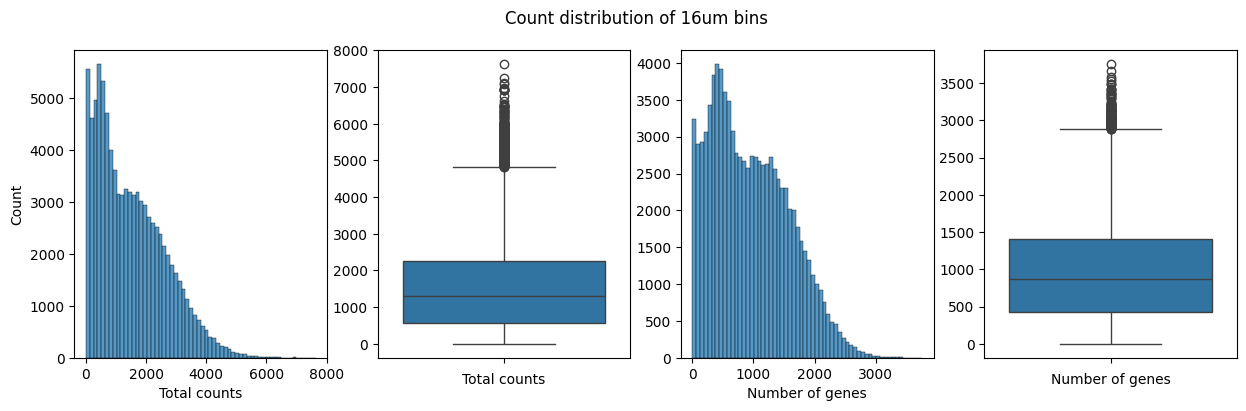

In [ ]:
# Count distribution per bin size
adata = sdata.tables["table_custom_bins"]
adata.obs["total_counts"] = adata.X.sum(axis=1)
adata.obs["n_genes_by_counts"] = (adata.X > 0).sum(axis=1)

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])

sns.boxplot(adata.obs["total_counts"], ax=axs[1])
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])

# Set overall title
fig.suptitle("Count distribution of {}um bins".format("16"))

# Set title and labels
axs[0].set_xlabel("Total counts")
axs[1].set_xlabel("Total counts")
axs[2].set_xlabel("Number of genes")
axs[3].set_xlabel("Number of genes")

# Turn off y-axis title
axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[3].set_ylabel("")

# Save plot
# plt.savefig("plots/histogram_count_genes_{}um.png".format(bin_size), dpi=300)


In [19]:
bin_names = ["table_custom_bins", "square_016um"]

for bin_name in bin_names:
    # Get average counts per bin
    print("Average counts in {}:".format(bin_name), end=" ")
    print(sdata.tables[bin_name].X.sum(axis=1).mean())

    # Get average number of genes per bin
    print("Average number of genes in {}:".format(bin_name), end=" ")
    print(sdata.tables[bin_name].X.astype(bool).sum(axis=1).mean())

Average counts in table_custom_bins: 1508.5011325900025
Average number of genes in table_custom_bins: 956.4206197356557
Average counts in square_016um: 1523.2577
Average number of genes in square_016um: 966.5035756264211


2025-06-17 13:38:51,693 - sparrow.plot._plot - WARNING - There are '2622' cells in provided shapes_layer 'square_shapes' not found in 'sdata.tables[table_custom_bins]' (linked through 'cell_ID'), these cells will not be plotted.


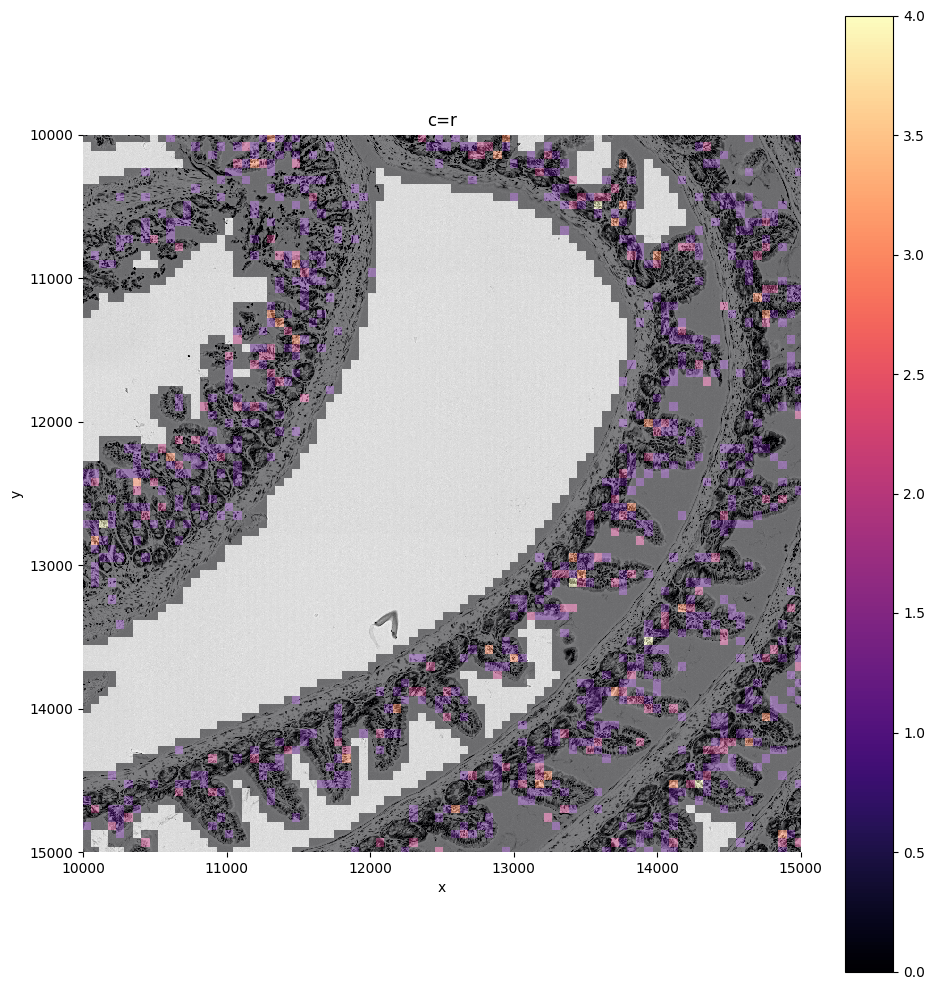

In [18]:
sp.pl.plot_shapes(
    sdata,
    img_layer = "Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="square_shapes", # shapes layer associated with our custom bin
    crd = [10000, 15000, 10000, 15000 ],
    channel="r",
    table_layer = "table_custom_bins",
    column="Lypla1",
    linewidth=0,
      )

In [30]:
import scanpy as sc

# you can then proceed doing normalization, and other processing steps using scanpy/squidpy etc...
adata_norm=sc.pp.normalize_total( sdata.tables[ "table_custom_bins" ] )

In [31]:
#import numpy as np

#np.where(sdata.tables[ "table_custom_bins" ].X[0].toarray() !=0 )

(array([0, 0, 0]), array([ 7337, 13546, 13963]))

In [32]:
#sdata.tables[ "table_custom_bins" ].X[0].toarray()[ :, 7337 ]

array([127.])

Now lets use a custom segmentation mask instead of a grid

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument '

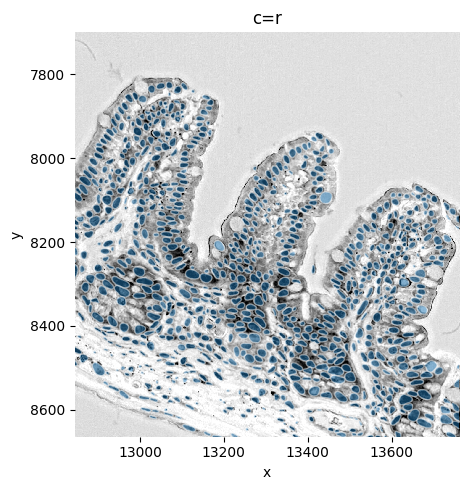

In [ ]:
import geopandas as gpd

from sparrow.datasets.registry import get_registry

registry = get_registry()

# read in a mask, and add it to the spatialdata object ( obtained from visium hd tutorial)
# https://www.10xgenomics.com/analysis-guides/segmentation-visium-hd

path_polygons = registry.fetch( "transcriptomics/visium_hd/mouse/masks.geojson" ) # custom segmentation of H&E

gdf = gpd.read_file(path_polygons)
gdf.index=gdf.index +1

sdata=sp.sh.add_shapes_layer(
    sdata,
    input=gdf,
    output_layer="segmentation_boundaries",
    overwrite=True,
      )

sp.pl.plot_shapes(
    sdata, 
    img_layer="Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="segmentation_boundaries",
    crd =[ 12844, 13760, 7700, 8664 ],
    figsize=(5,5) ,
    channel="r",
      )

In [5]:
labels_layer = "segmentation_mask"
sdata=sp.im.rasterize( sdata, shapes_layer="segmentation_boundaries", output_layer=labels_layer, overwrite=True )

2024-10-09 16:32:42,077 - sparrow.image._manager - WARNING - No dims parameter specified. Assuming order of dimension of provided array is ((c), (z), y, x)
2024-10-09 16:32:42,082 - sparrow.image._manager - INFO - Writing results to layer 'segmentation_mask'
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614

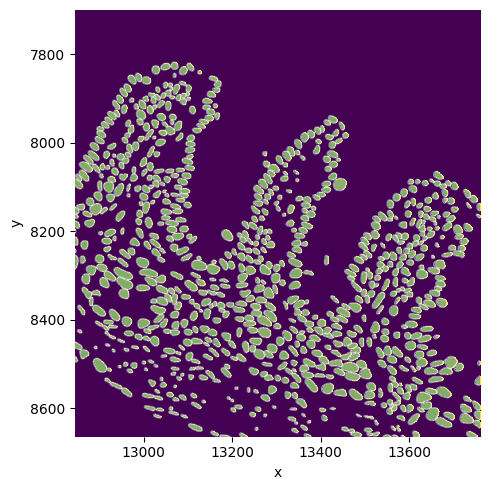

In [6]:
# sanity plot
sp.pl.plot_shapes(
    sdata, 
    labels_layer="segmentation_mask",
    shapes_layer="segmentation_boundaries",
    crd =[ 12844, 13760, 7700, 8664 ],
    figsize=(5,5),
    channel="r",
      )

In [8]:
# bin barcodes to the segmentation masks
sdata=sp.tb.bin_counts( 
    sdata,
    table_layer="square_002um",
    labels_layer="segmentation_mask",
    output_layer="table_custom_segmentation",
    append = False,
    overwrite=True,
      )

2024-10-09 16:34:30,115 - sparrow.table._allocation - INFO - Calculating cell counts.
2024-10-09 16:34:34,467 - sparrow.table._allocation - INFO - 
 Number of spots per bin  Frequency
                       1      59852
                       2      86037
                       3      71787
                       4      59368
                       5      32236
                       6      19129
                       7      11249
                       8       6894
                       9       4362
                      10       3060
                      11       1947
                      12       1427
                      13        942
                      14        699
                      15        409
                      16        294
                      17        211
                      18        139
                      19         94
                      20         57
                      21         58
                      22         35
                      23

2024-10-09 16:34:48,952 - sparrow.plot._plot - WARNING - There are '15' cells in provided shapes_layer 'segmentation_boundaries' not found in 'sdata.tables[table_custom_segmentation]' (linked through 'cell_ID'), these cells will not be plotted.


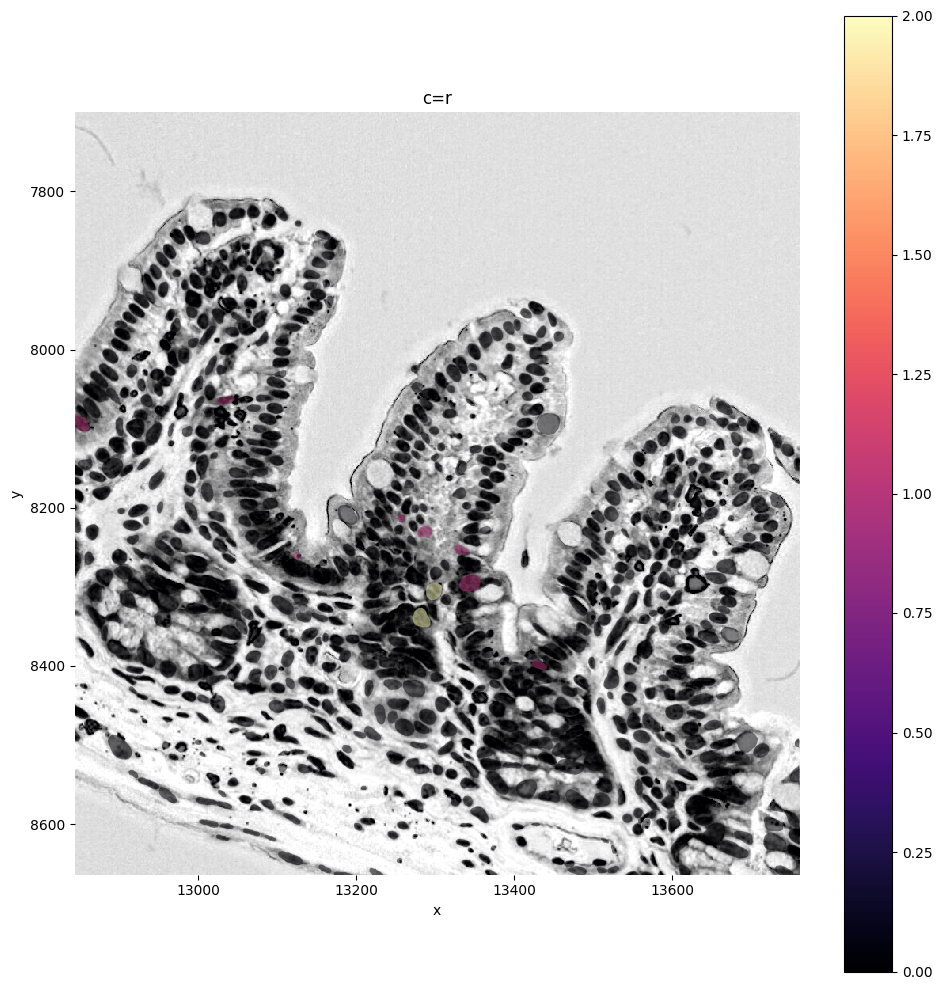

In [9]:
sp.pl.plot_shapes(
    sdata,
    img_layer = "Visium_HD_Mouse_Small_Intestine_full_image",
    shapes_layer="segmentation_boundaries", # shapes layer corresponding to labels layer
    crd = [ 12844, 13760, 7700, 8664 ],
    channel="r",
    table_layer = "table_custom_segmentation",
    column="Lypla1",
    linewidth=0,
      )